# S1 · ELBO 與重參數化 —— 變分推論的完整落地

**這本 notebook 做三件事**：

1. 把 ELBO 的兩個組成**各自驗證正確**（解析 KL vs Monte Carlo）
2. 量出**為什麼需要重參數化**（vs REINFORCE 的梯度變異數）
3. 在只看過 normal 胸片的 VAE 上，用 ELBO 當異常分數（**通關標準 1**）

> 第二本 notebook 才是重點：那個 AUROC 到底算好還是算爛。

---

## 為什麼是變分推論

前面九個專案都在算後驗：A1/C1/C2 用 MCMC，B2 用 nested sampling，E1 用 GP 的解析後驗。
它們有個共同前提 —— **參數夠少**。VAE 的「參數」是每張影像各自的 latent $z$，
1214 張圖就是 1214 個後驗，MCMC 完全不可行。

變分推論換一條路：不抽樣，改成**優化**。假設一族分佈 $q_\phi(z|x)$，
找裡面最接近真後驗的那個。代價是得到的是近似，而且近似有多差**你不知道**
（那正是 ELBO 與 $\log p(x)$ 的差距）。這個代價會在第二本 notebook 變成一個具體問題。

In [1]:
import os
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")  # 必須在 import torch 前
import sys
sys.path.insert(0, "../src")

import numpy as np
import torch
import matplotlib.pyplot as plt

import data as D, vae as V, train as T, experiments as X, evaluate as E, plots as P

DATA_DIR = "../../data/A_medical"
dev = V.device()
print("device:", dev, "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu")

device: cuda | NVIDIA GeForce RTX 5070 Ti


## 1 · 資料：只有 normal，pneumonia 完全不給模型看

異常偵測的設定是**單類別學習**：訓練時只有正常樣本，模型從沒見過異常。
這比二元分類難，但更貼近現實 —— 罕見病的標註樣本本來就湊不齊。

⚠️ 這裡的 in-distribution 與 anomaly 是**同一台機器、同一個部位、同一種影像**，
只差病灶。A3 專案做的是「胸片 vs 時尚商品」那種跨資料集 OOD，
低階像素統計就能分開。這裡不行 —— 至少直覺上不行，第二本 notebook 會檢驗這個直覺。

In [2]:
d = D.load(DATA_DIR)
for k, v in d.items():
    print(v.summary())

train[normal]: n=1214, x(1214, 1, 28, 28) in [0.000,1.000], mean=0.549
val[normal]: n=135, x(135, 1, 28, 28) in [0.000,1.000], mean=0.551
test[normal]: n=234, x(234, 1, 28, 28) in [0.000,0.996], mean=0.555
test[pneumonia]: n=390, x(390, 1, 28, 28) in [0.000,0.945], mean=0.569
test[all]: n=624, x(624, 1, 28, 28) in [0.000,0.996], mean=0.564


In [3]:
fig, axes = plt.subplots(2, 8, figsize=(13, 3.6))
rng = np.random.default_rng(0)
for row, (key, lab) in enumerate([("test_normal", "normal"), ("test_anomaly", "pneumonia")]):
    idx = rng.choice(d[key].n, 8, replace=False)
    for j, i in enumerate(idx):
        axes[row, j].imshow(d[key].x[i, 0], cmap="gray", vmin=0, vmax=1)
        axes[row, j].set_xticks([]); axes[row, j].set_yticks([]); axes[row, j].grid(False)
    axes[row, 0].set_ylabel(lab, fontsize=11)
plt.tight_layout(); plt.show()

/tmp/ipykernel_17291/226398775.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.tight_layout(); plt.show()


**肉眼可見的差別**：肺炎的片子普遍更白、更糊（肺泡實變讓肺野的黑色空氣被液體取代），
正常片的肋骨與血管紋理更清楚。

記住這個觀察 —— 它在第二本 notebook 會變成一個尷尬的結果。

---

## 2 · ELBO：它是什麼，以及它為什麼是下界

我們想要邊際似然 $\log p(x)$，但

$$p(x) = \int p(x|z)\,p(z)\,\mathrm{d}z$$

這個積分算不出來。變分推論引入 $q_\phi(z|x)$ 並做一步恆等變形：

$$\log p(x) = \underbrace{\mathbb{E}_{q}\left[\log p(x|z)\right] - \mathrm{KL}\left(q(z|x)\,\|\,p(z)\right)}_{\textbf{ELBO}} \;+\; \underbrace{\mathrm{KL}\left(q(z|x)\,\|\,p(z|x)\right)}_{\ge 0}$$

右邊第二項是「近似後驗離真後驗多遠」，恆非負 —— 所以 ELBO 是 $\log p(x)$ 的**下界**，
而且**差距正好就是近似的品質**。

這條式子有三個直接後果，本專案全部會用到：

| 讀出來的事 | 後果 |
|---|---|
| ELBO 低 ⟺ $\log p(x)$ 低 **或** 近似很差 | 用 ELBO 當異常分數時，這兩者被混在一起 |
| 兩項語意不同 | 重建項問「解得回來嗎」，KL 項問「latent 跑到先驗外了嗎」 |
| 下界可以收緊（IWAE） | 那會讓異常偵測變好嗎？**不是自明的** |

### 2.1 先驗證 KL 項算對了

對角高斯對標準常態的 KL 有解析式：

$$\mathrm{KL} = \tfrac{1}{2}\sum_j \left(\mu_j^2 + \sigma_j^2 - 1 - \log \sigma_j^2\right)$$

寫錯一個 $\tfrac12$、一個符號、漏掉 $-1$ —— **都不會拋錯**，只會讓訓練往一個
略微不對的目標收斂，而且結果看起來仍然合理。所以必須用 Monte Carlo 獨立檢查。

In [4]:
kv = V.verify_kl_formula(latent_dim=16, n_cases=24, n_samples=20000, seed=0)
print(f"KL 範圍            {kv['kl_range'][0]:.2f} – {kv['kl_range'][1]:.2f} nats")
print(f"最大絕對偏差       {kv['max_abs_diff']:.4f}")
print(f"最大偏差 (MC 標準誤){kv['max_diff_in_se_units']:.2f} SE")
print(f"24 個案例全在 4 SE 內：{kv['passed']}")

KL 範圍            10.50 – 48.52 nats
最大絕對偏差       0.1360
最大偏差 (MC 標準誤)1.88 SE
24 個案例全在 4 SE 內：True


⚠️ **第一版這個檢查「失敗」了，而問題出在測試設計。**

原本我拿**未訓練**模型的 encoder 輸出來測。未訓練時 $\mu\approx0$、$\log\sigma^2\approx0$，
於是 $\mathrm{KL}\approx0.003$ —— 在那個量級上相對誤差的分母趨近 0，
Monte Carlo 的取樣噪聲就讓相對誤差爆到 1.1，看起來像公式錯了。

改成直接抽合理範圍的 $(\mu, \log\sigma^2)$（讓 KL 落在 $O(1)$–$O(100)$），
公式的正確性才真的被檢驗到。**容差也不能亂設** —— 用 MC 自己的標準誤
$\mathrm{sd}(\log q - \log p)/\sqrt{n}$ 當尺度，「通過」才有依據。

### 2.2 重參數化：為什麼不能直接對抽樣微分

ELBO 的梯度要穿過「從 $q_\phi$ 抽樣」這個隨機步驟。把隨機性搬到與參數無關的地方：

$$z = \mu_\phi(x) + \sigma_\phi(x)\odot\epsilon,\qquad \epsilon\sim\mathcal{N}(0,I)$$

現在 $z$ 對 $\phi$ 可微。替代方案是 REINFORCE（score-function estimator）：

$$\nabla_\phi\,\mathbb{E}_q[f] = \mathbb{E}_q\!\left[f\,\nabla_\phi \log q_\phi\right]$$

它不要求 $f$ 可微，**兩者都是無偏的** —— 差別純粹在變異數，而變異數決定能不能用 SGD 訓練。

下面把這個差距量出來。為求公平：兩邊用**完全相同的 $\epsilon$**，
而且 REINFORCE 版加了 baseline（不加的話差距更誇張，那樣的對照不誠實）。

In [5]:
model, info = T.train(d["train_normal"], d["val_normal"], latent_dim=16,
                      beta=1.0, epochs=300, seed=0, verbose=True)
print(f"\n{info['epochs_run']} epochs / {info['seconds']}s, "
      f"best val ELBO {info['best_val_elbo']:.2f} @ epoch {info['best_epoch']}, "
      f"{info['n_params']:,} 參數")

  ep000 train_recon= -543.78 train_kl=  0.355 val_elbo= -535.79


  ep025 train_recon= -497.37 train_kl=  4.428 val_elbo= -499.64


  ep050 train_recon= -494.78 train_kl=  5.174 val_elbo= -497.89


  ep075 train_recon= -494.08 train_kl=  5.513 val_elbo= -497.62


  ep100 train_recon= -493.99 train_kl=  5.310 val_elbo= -497.02


...

  ep175 train_recon= -493.34 train_kl=  5.673 val_elbo= -497.23


  ep200 train_recon= -493.20 train_kl=  5.736 val_elbo= -496.95


  ep225 train_recon= -493.13 train_kl=  5.729 val_elbo= -496.78


  ep250 train_recon= -493.10 train_kl=  5.689 val_elbo= -496.79


  ep275 train_recon= -493.08 train_kl=  5.699 val_elbo= -496.50

277 epochs / 5.9s, best val ELBO -496.30 @ epoch 236, 314,721 參數


In [6]:
xb = torch.from_numpy(d["train_normal"].x[:128]).to(dev)
gv = V.grad_variance_comparison(model, xb, n_trials=60, seed=0)
print(f"重參數化    每參數梯度變異數 {gv['reparam']['mean_var']:.3e}   "
      f"梯度範數 {gv['reparam']['grad_norm_mean']:.1f} ± {gv['reparam']['grad_norm_sd']:.1f}")
print(f"REINFORCE   每參數梯度變異數 {gv['reinforce']['mean_var']:.3e}   "
      f"梯度範數 {gv['reinforce']['grad_norm_mean']:.1f} ± {gv['reinforce']['grad_norm_sd']:.1f}")
print(f"\n變異數比 = {gv['variance_ratio_reinforce_over_reparam']:,.0f}×"
      f"   （{gv['n_params']:,} 個 encoder 參數，{gv['n_trials']} 次試驗）")

重參數化    每參數梯度變異數 4.174e-04   梯度範數 18.3 ± 7.6
REINFORCE   每參數梯度變異數 3.750e-01   梯度範數 213.4 ± 139.7

變異數比 = 898×   （172,768 個 encoder 參數，60 次試驗）


這個比值就是「為什麼 2013 年之前 VAE 訓不起來」的答案 —— 不是模型不對，是梯度太吵。

順帶再驗一次 KL：這次用**訓練後**模型實際輸出的 $(\mu, \log\sigma^2)$，
確認在真實遇到的參數範圍內（含 `logvar` 被 clamp 到邊界時）解析式仍然成立。

In [7]:
kvt = V.verify_kl_analytic(model, xb, n_samples=4000, seed=0)
print(f"解析平均 KL {kvt['analytic_mean']:.4f}  vs  MC {kvt['mc_mean']:.4f}")
print(f"最大 |Δ| / 平均 KL = {kvt['max_diff_over_mean_kl']:.4f}   通過：{kvt['passed']}")

解析平均 KL 5.9159  vs  MC 5.9103
最大 |Δ| / 平均 KL = 0.0227   通過：True


---

## 3 · 通關標準 1：異常樣本的 ELBO 明顯較低嗎？

「明顯」和「可分離」都需要量化。三個指標：

- **AUROC**：把 $-\mathrm{ELBO}$ 當分數的排序能力（含 bootstrap 區間）
- **Cohen's d**：標準化的均值差
- **重疊係數**：兩個直方圖的交集面積，不依賴任何分佈假設

同時把 ELBO 拆開報告 —— 因為兩項的語意不同，異常可以只觸發其中一個。

In [8]:
sc_n = X.score_all(model, d["test_normal"], dev, iwae_K=20, seed=0)
sc_a = X.score_all(model, d["test_anomaly"], dev, iwae_K=20, seed=0)
table = X.auroc_table(sc_n, sc_a, n_boot=2000, seed=0)

print(f"{'分數':>20s}  {'AUROC':>7s}  {'95% CI':>16s}  {'Cohen d':>8s}  {'重疊':>6s}")
for k, v in table.items():
    s = v["separation"]
    print(f"{P.SCORE_LAB[k]:>20s}  {v['auroc']:7.4f}  "
          f"[{v['lo95']:.3f}, {v['hi95']:.3f}]  {s['cohens_d']:8.2f}  "
          f"{s['overlap_coefficient']:6.2f}")

                  分數    AUROC            95% CI   Cohen d      重疊
               −ELBO   0.7555  [0.715, 0.792]     -0.90    0.57
      −E[log p(x|z)]   0.7591  [0.720, 0.796]     -0.92    0.58
             KL(q‖p)   0.3814  [0.332, 0.428]     -0.52    0.75
      −IWAE$_{K=20}$   0.7547  [0.715, 0.791]     -0.90    0.58


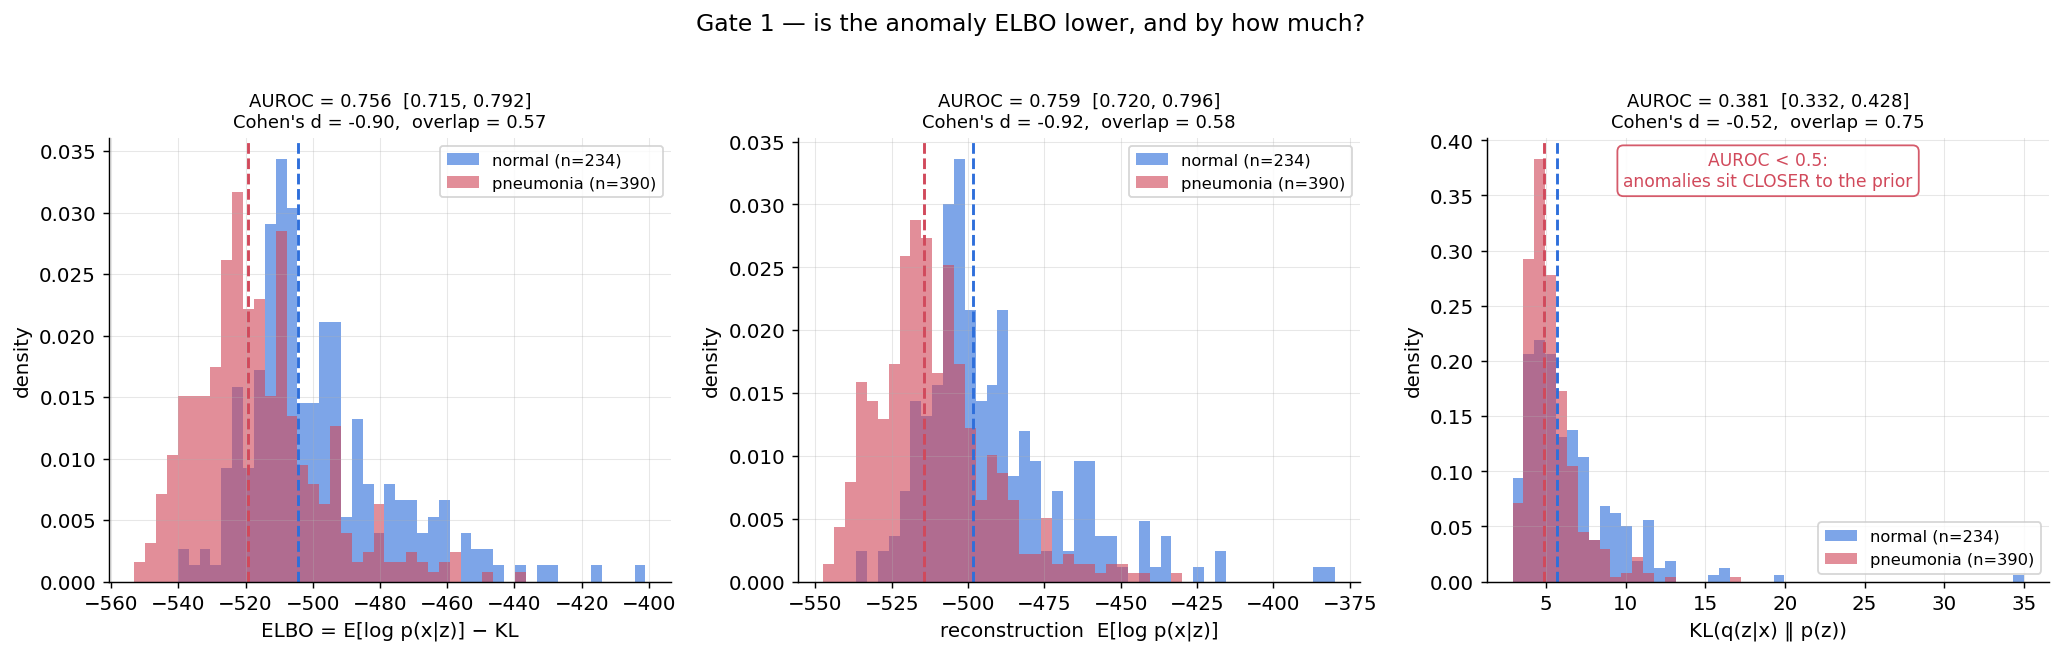

In [9]:
P.elbo_distributions(sc_n, sc_a, table, "../figures/02_elbo_distributions.png")
from IPython.display import Image; Image("../figures/02_elbo_distributions.png")

**三件事值得停下來看**：

1. **通關 1 成立，但「明顯」要打折**。$-\mathrm{ELBO}$ 的 AUROC 約 0.76，
   直方圖確實右移，但重疊係數 0.57 —— 超過一半的面積是重疊的。
   說「可分離」沒錯，說「明顯分離」就過頭了。

2. **判別力幾乎完全來自重建項**。$-\mathbb{E}[\log p(x|z)]$ 單獨的 AUROC
   和完整 ELBO 幾乎一樣。這代表 latent 那一項對分數幾乎沒貢獻。

3. **KL 項的 AUROC 低於 0.5** —— 而且明顯低。這與直覺相反：
   我原本預期異常影像的 latent 會被推到先驗外圍（KL 大）。
   實際上**異常的 latent 比正常的更靠近先驗**。

第 3 點的機制在第 4 節看得到。

## 4 · 重建：模型看得懂什麼

重建用**後驗均值** $\mu(x)$ 而不抽樣 —— 要展示的是模型的最佳猜測。

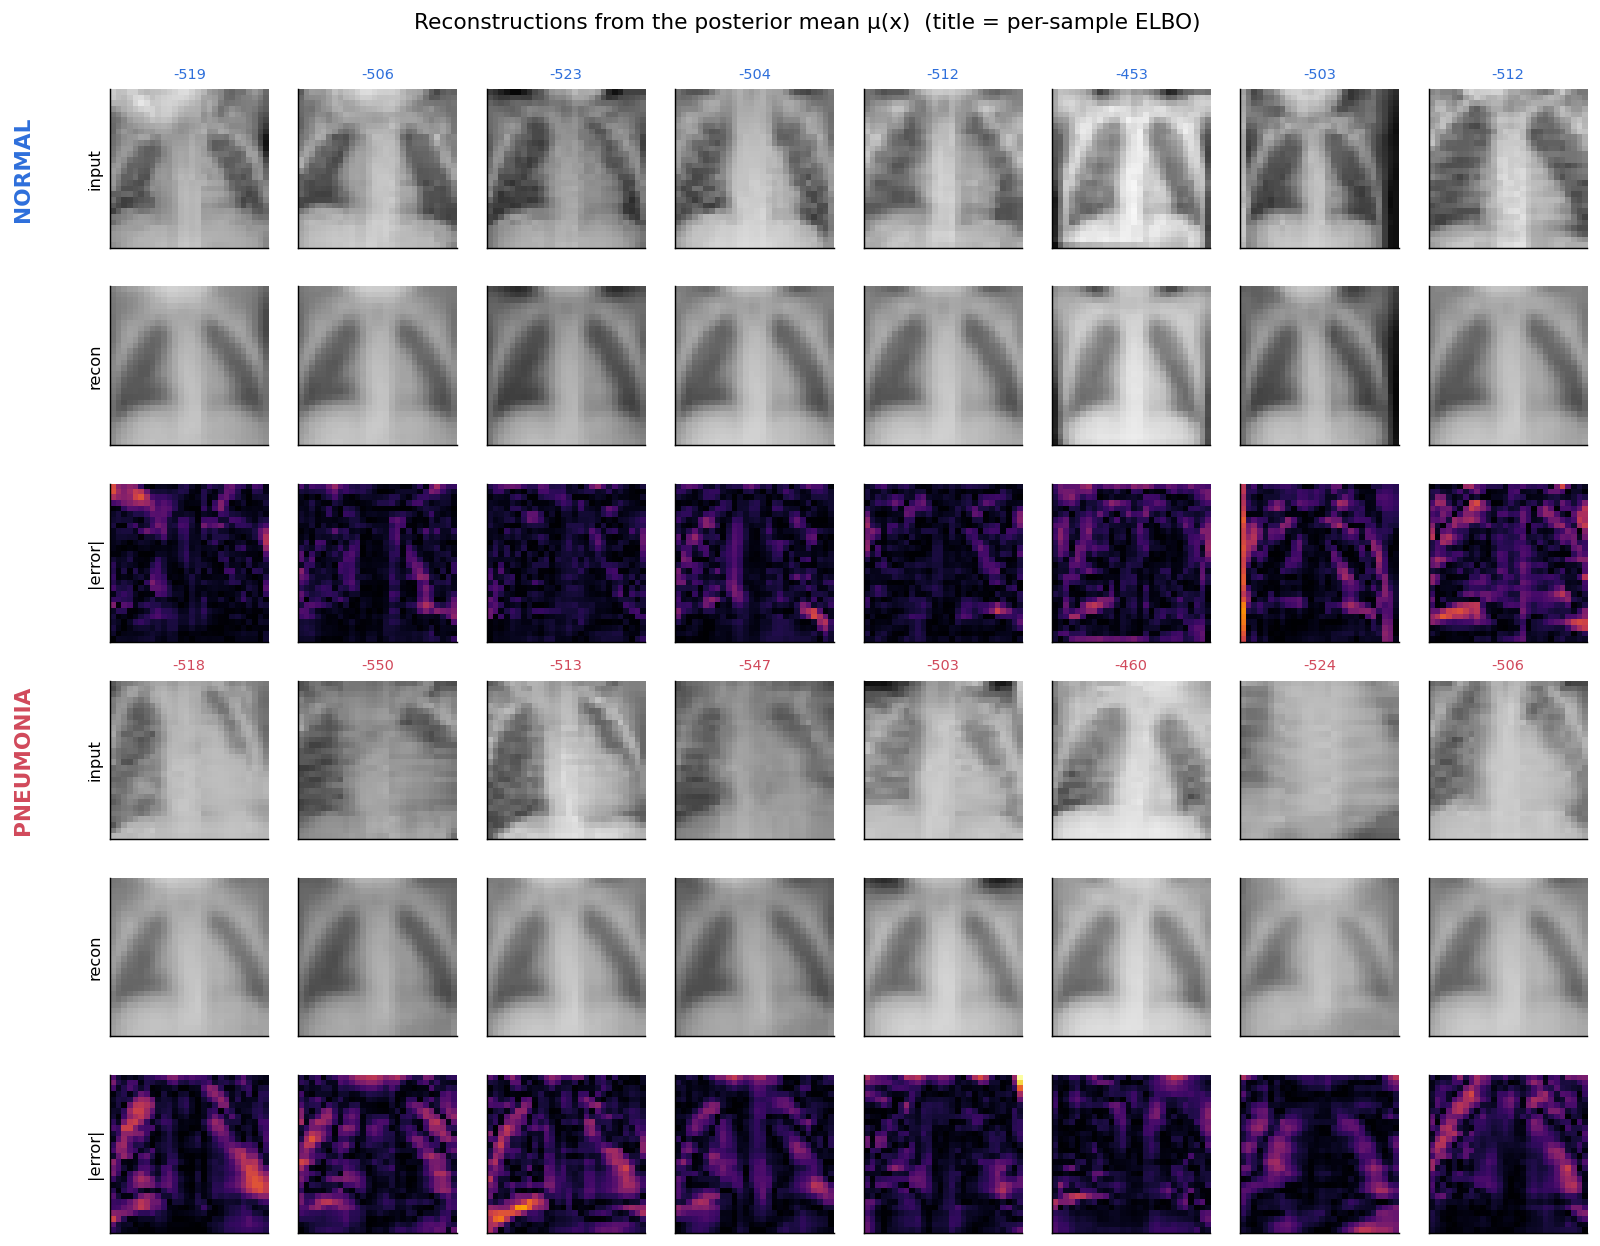

In [10]:
rec = X.reconstructions(model, {"test_normal": d["test_normal"],
                                "test_anomaly": d["test_anomaly"]}, dev, n=8, seed=0)
P.reconstructions(rec, "../figures/03_reconstructions.png")
Image("../figures/03_reconstructions.png")

**這張圖解釋了 KL 項的反直覺行為。**

VAE 在 1214 張圖上訓練，容量有限，學到的其實是「胸片的低頻結構」——
大致的輪廓、明暗分佈。兩組的重建**都很糊**，肋骨紋理誰都沒重建出來。

於是：肺炎影像本身就更糊、更平坦，**反而更接近 VAE 能表達的東西**。
encoder 不需要把 latent 推到很遠的位置就能生成一張糊圖 → KL 更小。
而重建誤差變大，是因為那些白色實變區的**絕對強度**對不上，不是因為結構複雜。

換句話說：ELBO 的兩項在這裡是**互相抵銷**的方向。這就是為什麼完整 ELBO
的 AUROC（0.756）比單獨的重建項（0.759）還低一點點。

---

## 小結

| 項目 | 結果 |
|---|---|
| KL 解析式 vs Monte Carlo | 24/24 案例在 4 個 MC 標準誤內 ✓ |
| 重參數化 vs REINFORCE | 梯度變異數差 **898×** |
| 通關 1（異常 ELBO 較低） | ✓ 成立，AUROC 0.756，但重疊係數 0.57 |
| 通關 2（ELBO 分解） | ✓ 重建項主導，KL 項**反向**（AUROC 0.38） |

到這裡為止，一切看起來是個成功的專案。

**但 0.756 到底是好還是壞？** 沒有對照，這個數字什麼都不是。
👉 [第二本 notebook](02_honest_evaluation.ipynb)